# Predictive Paradox — Electricity Demand Forecasting Pipeline
**Goal:** Predict the next hour's grid electricity demand (`demand_mw` at t+1)  
**Model type:** Classical ML only (LightGBM / XGBoost)  
**Evaluation metric:** MAPE (Mean Absolute Percentage Error)

## 0. Install & Import Libraries

In [1]:
# Run this cell first if you don't have these libraries installed
# !pip install lightgbm xgboost pandas numpy matplotlib seaborn scikit-learn openpyxl

In [2]:
import pandas as pd          # For working with tables (DataFrames)
import numpy as np           # For numerical operations
import matplotlib.pyplot as plt  # For plotting
import seaborn as sns        # For nicer plots
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error
import lightgbm as lgb

print('All libraries loaded successfully!')

All libraries loaded successfully!


---
## 1. Load the Data
We have 3 datasets:
- `PGCB_date_power_demand.xlsx` — hourly demand (our TARGET)
- `weather_data.xlsx` — hourly weather (temperature, humidity, precipitation)
- `economic_full_1.csv` — annual macroeconomic indicators

In [40]:
# --- Load all three datasets ---
# pd.read_excel reads .xlsx files into a DataFrame (a table)
# pd.read_csv reads .csv files

df_demand  = pd.read_excel('dataset/PGCB_date_power_demand.xlsx')
df_locate = pd.read_excel('dataset/weather_data.xlsx', nrows=2)
df_weather = pd.read_excel('dataset/weather_data.xlsx', skiprows=3)

# .shape tells us (rows, columns)
print('Demand  shape:', df_demand.shape)
print('Location shape:', df_locate.shape)
print('Weather shape:', df_weather.shape)

Demand  shape: (92650, 15)
Location shape: (1, 6)
Weather shape: (107304, 10)
Econ    shape: (1516, 69)


In [42]:
train_demand_df = df_demand[df_demand['datetime'].dt.year < 2024]
train_weather_df = df_weather[df_weather['time'].dt.year < 2024]

test_demand_df = df_demand[df_demand['datetime'].dt.year >= 2024]
test_weather_df = df_weather[df_weather['time'].dt.year >= 2024]

train_demand_df.to_excel('dataset/train_demand_data.xlsx')
train_weather_df.to_excel('dataset/train_weather_data.xlsx')

test_demand_df.to_excel('dataset/test_demand_data.xlsx')
test_weather_df.to_excel('dataset/test_weather_data.xlsx')


In [4]:
# .head() shows the first 5 rows — always do this to understand your data
print('=== DEMAND DATA ===')
display(df_demand.head())

print('=== LOCATION DATA ===')
display(df_locate.head())

print('=== WEATHER DATA ===')
display(df_weather.head())

print('=== ECONOMIC DATA ===')
display(df_econ.head())

=== DEMAND DATA ===


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN


=== LOCATION DATA ===


,latitude,longitude,elevation,utc_offset_seconds,timezone,timezone_abbreviation
0,23.7961,90.3805,9,21600,Asia/Dhaka,GMT+6


=== WEATHER DATA ===


,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
0,2014-01-01 00:00:00,13.9,89,13.3,0.0,12.1,16.4,313,0,0.0
1,2014-01-01 01:00:00,13.6,91,13.2,0.0,12.1,16.0,317,0,0.0
2,2014-01-01 02:00:00,13.3,91,12.8,0.0,11.9,15.7,317,0,0.0
3,2014-01-01 03:00:00,13.0,92,12.5,0.0,11.8,15.4,319,0,0.0
4,2014-01-01 04:00:00,12.7,93,12.2,0.0,11.6,15.2,322,0,0.0


=== ECONOMIC DATA ===


,Country Name,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,X,"Intentional homicides, male (per 100,000 male)",VC.IHR.PSRC.MA.P5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,X,Battle-related deaths (number of people),VC.BTL.DETH,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,41.000000,47.000000,NaN,NaN,2.000000,NaN,2.000000,NaN,2.000000,NaN
2,X,Voice and Accountability: Percentile Rank,VA.PER.RNK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,30.541872,30.049261,27.184465,26.570047,26.570047,28.019323,28.019323,27.450981,NaN,NaN
3,X,Transport services (% of commercial service ex...,TX.VAL.TRAN.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,20.820301,21.484188,22.048898,19.559759,22.257010,27.162699,25.520411,17.176637,23.495141,NaN
4,X,"Computer, communications and other services (%...",TX.VAL.OTHR.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,64.068305,57.202109,62.313903,63.578283,67.395621,64.565856,63.537174,67.817057,65.566600,NaN


In [5]:
# .info() shows column names, data types, and how many non-null values exist
# This is crucial for spotting missing data!
print('=== DEMAND INFO ===')
df_demand.info()
print()
print('=== LOCATION INFO ===')
df_locate.info()
print()
print('=== WEATHER INFO ===')
df_weather.info()

=== DEMAND INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              92650 non-null  datetime64[us]
 1   generation_mw         92650 non-null  float64       
 2   demand_mw             92650 non-null  int64         
 3   load_shedding         92650 non-null  int64         
 4   gas                   92650 non-null  int64         
 5   liquid_fuel           92650 non-null  int64         
 6   coal                  92650 non-null  int64         
 7   hydro                 92650 non-null  int64         
 8   solar                 70517 non-null  float64       
 9   wind                  18676 non-null  float64       
 10  india_bheramara_hvdc  92650 non-null  int64         
 11  india_tripura         92650 non-null  int64         
 12  india_adani           7338 non-null   float64       
 13  nepal  

---
## 2. Data Preparation & Cleaning

### 2A. Fix the Demand Dataset

In [6]:
# STEP 1: Convert the datetime column to a proper datetime type
# *** IMPORTANT: Replace 'datetime_column_name' with the actual column name you see above ***

cols = ['generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc', 'india_tripura', 'india_adani', 'nepal']

# For demand data:
# pd.to_datetime converts strings like '2021-01-01 00:00:00' into actual datetime objects
df_demand['datetime'] = pd.to_datetime(df_demand['datetime'])  # <-- replace
df_weather['datetime'] = pd.to_datetime(df_weather['time'])  # <-- replace
df_weather = df_weather.drop('time', axis=1)
df_demand[cols] = df_demand[cols].fillna(0)

# Sort by time (very important for time series!)
df_demand  = df_demand.sort_values('datetime').reset_index(drop=True)
df_weather = df_weather.sort_values('datetime').reset_index(drop=True)

print('Demand date range:', df_demand['datetime'].min(), 'to', df_demand['datetime'].max())
print('Weather date range:', df_weather['datetime'].min(), 'to', df_weather['datetime'].max())

Demand date range: 2015-04-19 00:00:00 to 2025-06-17 12:00:00
Weather date range: 2014-01-01 00:00:00 to 2026-03-29 23:00:00


In [7]:
# STEP 2: Identify the datetime column
# Look at df_demand.columns to find which column holds the timestamp
print('Demand columns:', df_demand.columns.tolist())
print('Location columns:', df_locate.columns.tolist())
print('Weather columns:', df_weather.columns.tolist())

Demand columns: ['datetime', 'generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc', 'india_tripura', 'india_adani', 'nepal', 'remarks']
Location columns: ['latitude', 'longitude', 'elevation', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation']
Weather columns: ['temperature_2m (°C)', 'relative_humidity_2m (%)', 'apparent_temperature (°C)', 'precipitation (mm)', 'dew_point_2m (°C)', 'soil_temperature_0_to_7cm (°C)', 'wind_direction_10m (°)', 'cloud_cover (%)', 'sunshine_duration (s)', 'datetime']


In [8]:
# STEP 3: Check for and remove DUPLICATE timestamps
# duplicated() returns True for rows that are duplicates
n_dupes = df_demand.duplicated(subset='datetime').sum()
print(f'Number of duplicate timestamps in demand data: {n_dupes}')

# Keep only the first occurrence of each timestamp
df_demand = df_demand.drop_duplicates(subset='datetime', keep='first')
print(f'Demand rows after removing duplicates: {len(df_demand)}')

Number of duplicate timestamps in demand data: 432
Demand rows after removing duplicates: 92218


In [9]:
import bisect

def k_nearest(L, x, k):
    pos = bisect.bisect_left(L, x)
    
    left = pos - 1
    right = pos
    
    result = []
    
    while k > 0 and (left >= 0 or right < len(L)):
        if left < 0:
            result.append(L[right])
            right += 1
        elif right >= len(L):
            result.append(L[left])
            left -= 1
        else:
            if abs(L[left] - x) <= abs(L[right] - x):
                result.append(L[left])
                left -= 1
            else:
                result.append(L[right])
                right += 1
        k -= 1
    
    return result

In [10]:
# STEP 4: Generalize Ratio to fill NaN breakdown of generation_mv
LEN = 24
cols = ['gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc', 'india_tripura', 'india_adani', 'nepal']
df_demand[cols] = df_demand[cols].astype(float)

filtered_indices = df_demand.index[(df_demand[cols].notna() & (df_demand[cols] != 0)).any(axis=1)]
masked = df_demand.loc[(df_demand[cols].isna() | (df_demand[cols] == 0)).all(axis=1)]

for idx, row in masked.iterrows():
    valid_indices = k_nearest(filtered_indices, idx, LEN)

    valid_rows = df_demand.loc[valid_indices, ['generation_mw'] + cols]
    for col in cols:
        valid_rows[col] = valid_rows[col] / valid_rows['generation_mw']
    valid_means = valid_rows[cols].mean()
    sum = 0.0
    for col in cols:
        sum += valid_means[col]
    valid_means = valid_means / sum

    df_demand.loc[idx, cols] = df_demand.loc[idx, 'generation_mw'] * valid_means

In [11]:
print(df_demand.head())

             datetime  generation_mw  demand_mw  load_shedding          gas  \
0 2015-04-19 00:00:00         4821.0       4821              0  3179.507083   
1 2015-04-19 01:00:00         3612.0       3612              0  2382.157143   
2 2015-04-19 02:00:00         3727.0       3727              0  2458.001016   
3 2015-04-19 03:00:00         3632.0       3632              0  2395.347382   
4 2015-04-19 04:00:00         3641.0       3641              0  2401.282989   

   liquid_fuel        coal      hydro  solar  wind  india_bheramara_hvdc  \
0   959.784564  122.384281  32.258259    0.0   0.0            527.065812   
1   719.091858   91.693014  24.168603    0.0   0.0            394.889383   
2   741.986532   94.612365  24.938090    0.0   0.0            407.461996   
3   723.073540   92.200727  24.302427    0.0   0.0            397.075924   
4   724.865297   92.429198  24.362647    0.0   0.0            398.059868   

   india_tripura  india_adani  nepal remarks  
0            0.0     

In [12]:
def custom_avg(x : np.array):
    if x.size == 2:
        if np.isnan(x[0]):
            return x[1]
        elif np.isnan(x[1]):
            return x[0]
        else:
            return x.mean()
    if np.isnan(x[0]) and np.isnan(x[2]):
        return x[1]
    elif np.isnan(x[0]):
        return (3 * x[1] + x[2]) / 4
    else:
        return (2 * x[1] + x[0] + x[2]) / 4

In [13]:
# STEP 5: Manage half-hourly data and process data to be available at 1h intervals
df_demand = df_demand.set_index('datetime')
cols = ['generation_mw', 'demand_mw']

print(f'Demand rows before processing half hourly values : {len(df_demand)}')

df_demand = df_demand.resample('30min').asfreq()

df_demand[cols] = df_demand[cols].rolling('90min', center=True, min_periods=1).apply(custom_avg, raw=True)
df_demand = df_demand.resample('h').first()

cols = ['generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc', 'india_tripura', 'india_adani', 'nepal']

df_demand[cols] = df_demand[cols].interpolate(method='linear', limit=6)
df_demand = df_demand.dropna(subset=cols, how='all')

df_demand = df_demand.reset_index()

print(f'Demand rows after processing half hourly values : {len(df_demand)}')

Demand rows before processing half hourly values : 92218
Demand rows after processing half hourly values : 88455


### 2B. Anomaly Detection — Remove Extreme Spikes

**Our approach:** Rolling Z-Score
- For each point, calculate how many standard deviations it is from its local rolling mean.
- If it's more than 3.5 standard deviations away, it's an anomaly.
- This is better than a global threshold because demand varies by season.

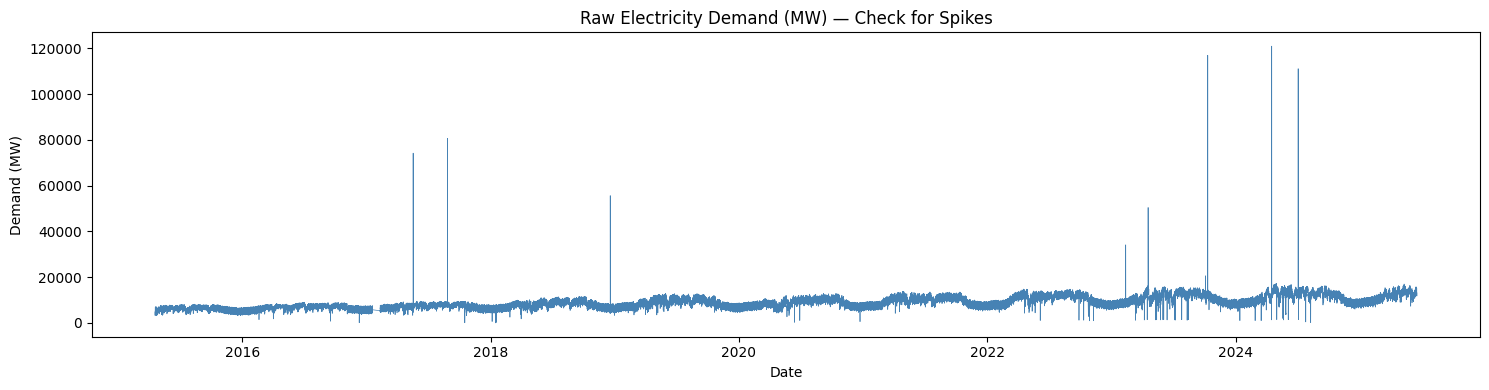

In [14]:
# Plot the raw demand to visually see spikes
plt.figure(figsize=(15, 4))
plt.plot(df_demand['datetime'], df_demand['demand_mw'], linewidth=0.5, color='steelblue')
plt.title('Raw Electricity Demand (MW) — Check for Spikes')
plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.tight_layout()
plt.show()

Number of anomalies detected: 168


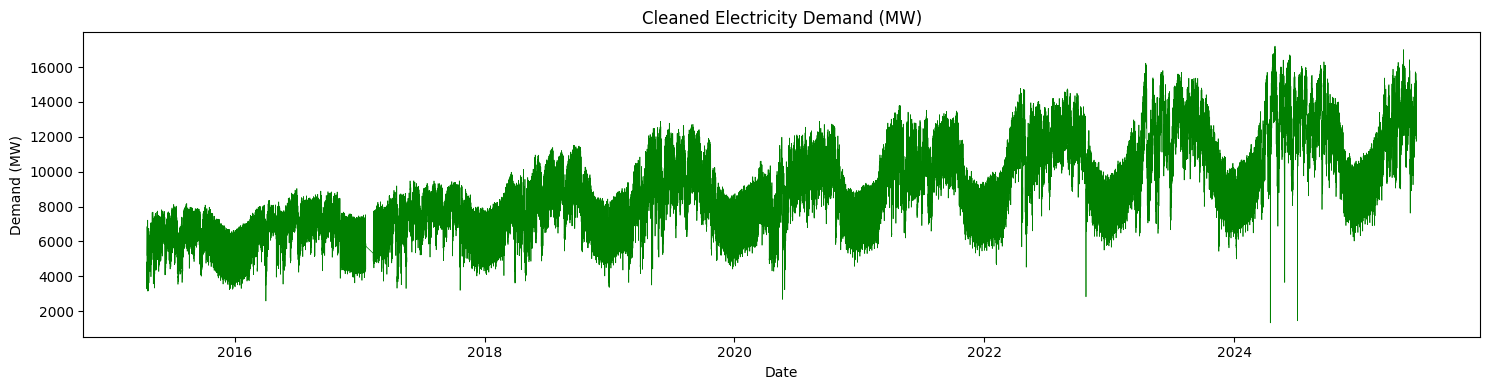

In [15]:
# Rolling Z-Score Anomaly Detection
# Window = 168 hours = 1 week (captures weekly seasonality)
WINDOW = 168
THRESHOLD = 2.5  # Points beyond 2.5 std deviations are anomalies

rolling_mean = df_demand['demand_mw'].rolling(window=WINDOW, center=True, min_periods=1).mean()
rolling_std  = df_demand['demand_mw'].rolling(window=WINDOW, center=True, min_periods=1).std()

# Z-score: how far is each point from the rolling average?
z_scores = (df_demand['demand_mw'] - rolling_mean) / (rolling_std + 1e-8)

# Mark anomalies
is_anomaly = z_scores.abs() > THRESHOLD
print(f'Number of anomalies detected: {is_anomaly.sum()}')

# Replace anomalies with the rolling mean (smooth them out)
df_demand.loc[is_anomaly, 'demand_mw'] = rolling_mean[is_anomaly]

# Plot again to verify anomalies are removed
plt.figure(figsize=(15, 4))
plt.plot(df_demand['datetime'], df_demand['demand_mw'], linewidth=0.5, color='green')
plt.title('Cleaned Electricity Demand (MW)')
plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.tight_layout()
plt.show()

### 2D. Merge Weather Data

In [16]:
# Merge weather with demand on the datetime column
# how='left' means: keep all demand rows, attach weather if available
df = df_demand.merge(df_weather, on='datetime', how='left')

print('Combined dataset shape:', df.shape)
print(df.head())
print('Missing values in combined data:')
print(df.isnull().sum())

# Fill remaining weather NaNs with forward fill (use last known weather value)
weather_cols = ['temperature_2m (°C)', 'relative_humidity_2m (%)', 'apparent_temperature (°C)', 'precipitation (mm)', 'dew_point_2m (°C)', 'soil_temperature_0_to_7cm (°C)', 'wind_direction_10m (°)', 'cloud_cover (%)', 'sunshine_duration (s)']  # <-- replace with real names
df[weather_cols] = df[weather_cols].ffill().bfill()

Combined dataset shape: (88455, 24)
             datetime  generation_mw  demand_mw  load_shedding          gas  \
0 2015-04-19 00:00:00         4821.0     4821.0            0.0  3179.507083   
1 2015-04-19 01:00:00         3612.0     3612.0            0.0  2382.157143   
2 2015-04-19 02:00:00         3727.0     3727.0            0.0  2458.001016   
3 2015-04-19 03:00:00         3632.0     3632.0            0.0  2395.347382   
4 2015-04-19 04:00:00         3641.0     3641.0            0.0  2401.282989   

   liquid_fuel        coal      hydro  solar  wind  ...  remarks  \
0   959.784564  122.384281  32.258259    0.0   0.0  ...      NaN   
1   719.091858   91.693014  24.168603    0.0   0.0  ...      NaN   
2   741.986532   94.612365  24.938090    0.0   0.0  ...      NaN   
3   723.073540   92.200727  24.302427    0.0   0.0  ...      NaN   
4   724.865297   92.429198  24.362647    0.0   0.0  ...      NaN   

   temperature_2m (°C)  relative_humidity_2m (%)  apparent_temperature (°C)  \
0

### Save Processed and Merged Data:

In [17]:
df.to_excel('Dataset/merged.xlsx')

---
## 3. Feature Engineering

This is the most important step. Since we use classical ML (not LSTMs), we must manually create features that capture time patterns.

In [18]:
# Sort by datetime to ensure correct lag computation
df = df.sort_values('datetime').reset_index(drop=True)

# =============================================
# A. CALENDAR / TIME FEATURES
# These tell the model: "what time is it?"
# =============================================
df['hour']        = df['datetime'].dt.hour          # 0-23
df['day_of_week'] = df['datetime'].dt.dayofweek     # 0=Monday, 6=Sunday
df['month']       = df['datetime'].dt.month         # 1-12
df['day_of_year'] = df['datetime'].dt.dayofyear     # 1-365
df['week_of_year']= df['datetime'].dt.isocalendar().week.astype(int)
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)  # 1 if Sat/Sun
df['quarter']     = df['datetime'].dt.quarter       # 1-4

# Cyclical encoding: hour 23 and hour 0 are close in reality,
# but numerically 23 and 0 are far apart. Sin/cos fixes this.
df['hour_sin']  = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['dow_sin']   = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']   = np.cos(2 * np.pi * df['day_of_week'] / 7)

print('Calendar features added.')

Calendar features added.


In [19]:
# =============================================
# B. LAG FEATURES
# These tell the model: "what was demand recently?"
# .shift(n) moves values n rows forward (so at row t, you see value from t-n)
# This avoids data leakage — we only use past values!
# =============================================

# Short-term lags (recent hours)
for lag in [1, 2, 3, 6, 12]:
    df[f'lag_{lag}h'] = df['demand_mw'].shift(lag)

# Same time yesterday and last week
df['lag_24h']  = df['demand_mw'].shift(24)   # 1 day ago, same hour
df['lag_48h']  = df['demand_mw'].shift(48)   # 2 days ago
df['lag_168h'] = df['demand_mw'].shift(168)  # 7 days ago, same hour (most powerful!)
df['lag_336h'] = df['demand_mw'].shift(336)  # 14 days ago

print('Lag features added.')

Lag features added.


In [20]:
# =============================================
# C. ROLLING WINDOW FEATURES
# These tell the model: "what was the recent trend/variability?"
# We use .shift(1) BEFORE rolling to avoid leakage (don't include current row)
# =============================================

demand_shifted = df['demand_mw'].shift(1)  # start from t-1

# Rolling mean: average demand over the past N hours
for window in [3, 6, 12, 24, 168]:
    df[f'roll_mean_{window}h'] = demand_shifted.rolling(window=window, min_periods=1).mean()
    df[f'roll_std_{window}h']  = demand_shifted.rolling(window=window, min_periods=1).std()

# Rolling min/max over last 24 hours
df['roll_min_24h'] = demand_shifted.rolling(window=24, min_periods=1).min()
df['roll_max_24h'] = demand_shifted.rolling(window=24, min_periods=1).max()

print('Rolling features added.')

Rolling features added.


In [21]:
# =============================================
# D. DEFINE THE TARGET VARIABLE
# We want to predict demand_mw at t+1
# .shift(-1) moves values 1 row backward (so at row t, target = row t+1's demand)
# =============================================
df['target_demand_mw'] = df['demand_mw'].shift(-1)

# Drop rows with NaN target or NaN lags (first/last rows will have NaN)
df = df.dropna(subset=['target_demand_mw', 'lag_168h'])

print(f'Final dataset shape after feature engineering: {df.shape}')
display(df.head())

Final dataset shape after feature engineering: (88278, 59)


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,...,roll_std_6h,roll_mean_12h,roll_std_12h,roll_mean_24h,roll_std_24h,roll_mean_168h,roll_std_168h,roll_min_24h,roll_max_24h,target_demand_mw
168,2015-04-26 21:00:00,6363.0,6363.0,0.0,4961.0,746.0,160.0,44.0,0.0,0.0,...,14.667297,5720.220000,652.851426,4922.485000,957.753626,5135.839524,1119.897948,3624.0,6214.04,5995.0
169,2015-04-26 22:00:00,5995.0,5995.0,0.0,4822.0,510.0,164.0,46.0,0.0,0.0,...,68.122337,5862.720000,581.447834,4999.693333,996.942909,5145.018095,1123.614974,3624.0,6363.00,5587.0
170,2015-04-26 23:00:00,5587.0,5587.0,0.0,4586.0,340.0,162.0,46.0,0.0,0.0,...,117.253520,5986.386667,396.086209,5073.235000,1002.778645,5159.202619,1119.179005,3624.0,6363.00,5236.0
171,2015-04-27 00:00:00,5236.0,5236.0,0.0,4417.0,159.0,162.0,46.0,0.0,0.0,...,274.627174,6024.699167,320.441011,5148.401667,968.899930,5170.274048,1114.114692,3624.0,6363.00,5064.0
172,2015-04-27 01:00:00,5064.0,5064.0,0.0,4282.0,116.0,162.0,46.0,0.0,0.0,...,435.405322,6020.240833,331.771676,5215.526667,912.960429,5179.821667,1107.707690,3624.0,6363.00,4851.0


---
## 4. Train / Test Split (Chronological)

**Critical rule:** Never shuffle time series data. All of 2023 is our test set.

In [22]:
# Define feature columns (everything except datetime, raw demand, and target)
exclude_cols = ['datetime', 'demand_mw', 'target_demand_mw', 'year', 'remarks', 'generation_mw']
feature_cols = [c for c in df.columns if c not in exclude_cols]

print(f'Number of features: {len(feature_cols)}')
print('Features:', feature_cols)

Number of features: 54
Features: ['load_shedding', 'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc', 'india_tripura', 'india_adani', 'nepal', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'apparent_temperature (°C)', 'precipitation (mm)', 'dew_point_2m (°C)', 'soil_temperature_0_to_7cm (°C)', 'wind_direction_10m (°)', 'cloud_cover (%)', 'sunshine_duration (s)', 'hour', 'day_of_week', 'month', 'day_of_year', 'week_of_year', 'is_weekend', 'quarter', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'lag_1h', 'lag_2h', 'lag_3h', 'lag_6h', 'lag_12h', 'lag_24h', 'lag_48h', 'lag_168h', 'lag_336h', 'roll_mean_3h', 'roll_std_3h', 'roll_mean_6h', 'roll_std_6h', 'roll_mean_12h', 'roll_std_12h', 'roll_mean_24h', 'roll_std_24h', 'roll_mean_168h', 'roll_std_168h', 'roll_min_24h', 'roll_max_24h']


In [23]:
# Chronological split: train = before 2023, test = 2023
train_df = df[df['datetime'].dt.year < 2024].copy()
test_df  = df[df['datetime'].dt.year >= 2024].copy()

X_train = train_df[feature_cols]
y_train = train_df['target_demand_mw']

X_test  = test_df[feature_cols]
y_test  = test_df['target_demand_mw']

print(f'Training rows: {len(X_train)}')
print(f'Test rows:     {len(X_test)}')
print(f'Train period: {train_df["datetime"].min()} to {train_df["datetime"].max()}')
print(f'Test  period: {test_df["datetime"].min()} to {test_df["datetime"].max()}')

Training rows: 75474
Test rows:     12804
Train period: 2015-04-26 21:00:00 to 2023-12-31 23:00:00
Test  period: 2024-01-01 00:00:00 to 2025-06-17 11:00:00


---
## 5. Model Training

In [27]:

# Hyper Tuning Variables
param_dist = {
    "n_estimators": [200, 500, 1000, 1500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "num_leaves": [31, 63, 127, 255],
    "max_depth": [-1, 5, 10, 15],
    "min_child_samples": [10, 20, 50, 100],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [0, 0.1, 1]
}
param_one = {
    "n_estimators": [1000],
    "learning_rate": [0.05],
    "num_leaves": [63],
    "min_child_samples": [20],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

In [35]:
# === LightGBM Model ===
# LightGBM is a gradient boosting framework — fast and very effective
# for tabular data.

from sklearn.model_selection import RandomizedSearchCV

model = lgb.LGBMRegressor(
    random_state=42,
    verbose=1
)
model2 = RandomizedSearchCV(
    model,
    param_distributions=param_one,
    n_iter=1,              # increase for better results
    scoring="neg_mean_squared_error",
    cv=2,
    verbose=1,
    n_jobs=-1
)

# train model
print(X_train.shape)
model.fit(X_train, y_train)

print('Best Parameters:')
print(model.best_params_)
    
model = model.best_estimator_

print('LightGBM training complete!')

(75474, 54)
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.796044
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.101774
[LightGBM] [Debug] init for col-wise cost 0.010605 seconds, init for row-wise cost 0.018283 seconds
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020228 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Dense Multi-Val Bin
[LightGBM] [Info] Total Bins 9576
[LightGBM] [Info] Number of data points in the train set: 75474, number of used features: 52
[LightGBM] [Info] Start training from score 8324.502457
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 6
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 6
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 6
[L

AttributeError: 'LGBMRegressor' object has no attribute 'best_params_'

---
## 6. Evaluation

In [36]:
# Predict on the test set
y_pred = model.predict(X_test)

# Calculate MAPE
# MAPE = average of |actual - predicted| / actual * 100%
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
print(f'\n=== TEST MAPE: {mape:.2f}% ===')
print()
if mape < 5:
    print('Excellent! Less than 5% error is industry-grade.')
elif mape < 10:
    print('Good. Less than 10% is acceptable for short-term forecasting.')
else:
    print('Room for improvement. Consider more lag features or hyperparameter tuning.')


=== TEST MAPE: 3.33% ===

Excellent! Less than 5% error is industry-grade.


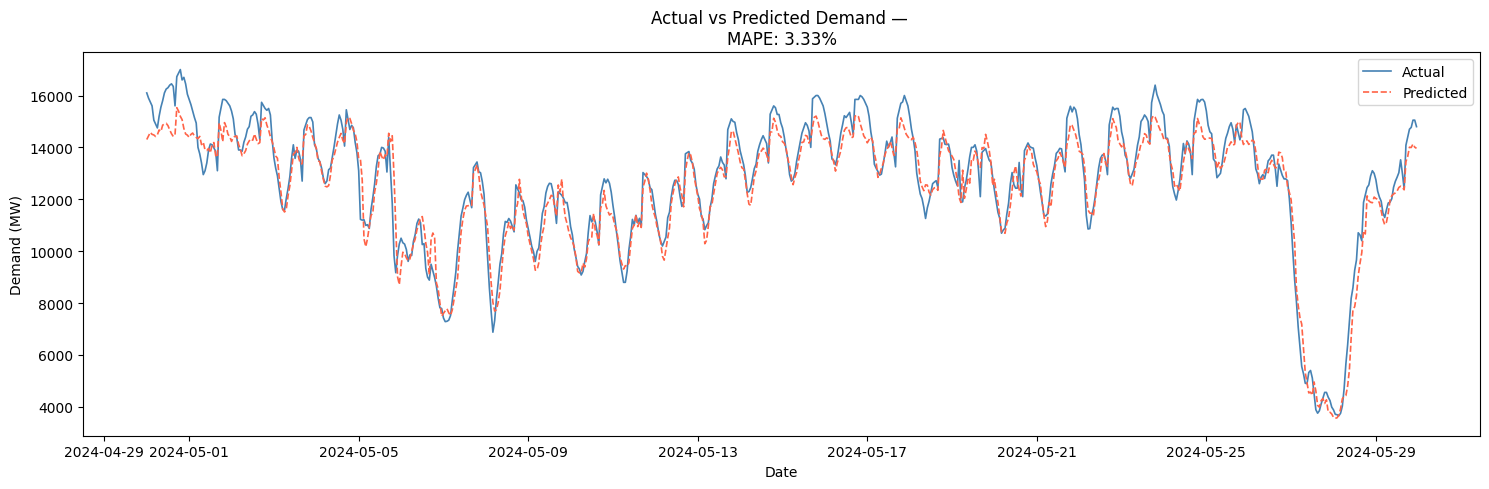

In [37]:
# Plot actual vs predicted for first 2 weeks of 2024
fig, ax = plt.subplots(figsize=(15, 5))

start = 24 * 30 * 4
end = 24 * 30 * 5  # 14 days
ax.plot(test_df['datetime'].values[start:end], y_test.values[start:end],
        label='Actual', color='steelblue', linewidth=1.2)
ax.plot(test_df['datetime'].values[start:end], y_pred[start:end],
        label='Predicted', color='tomato', linewidth=1.2, linestyle='--')

ax.set_title(f'Actual vs Predicted Demand — \nMAPE: {mape:.2f}%')
ax.set_xlabel('Date')
ax.set_ylabel('Demand (MW)')
ax.legend()
plt.tight_layout()
plt.savefig('graphs/actual_vs_predicted.png', dpi=150)
plt.show()

---
## 7. Feature Importance

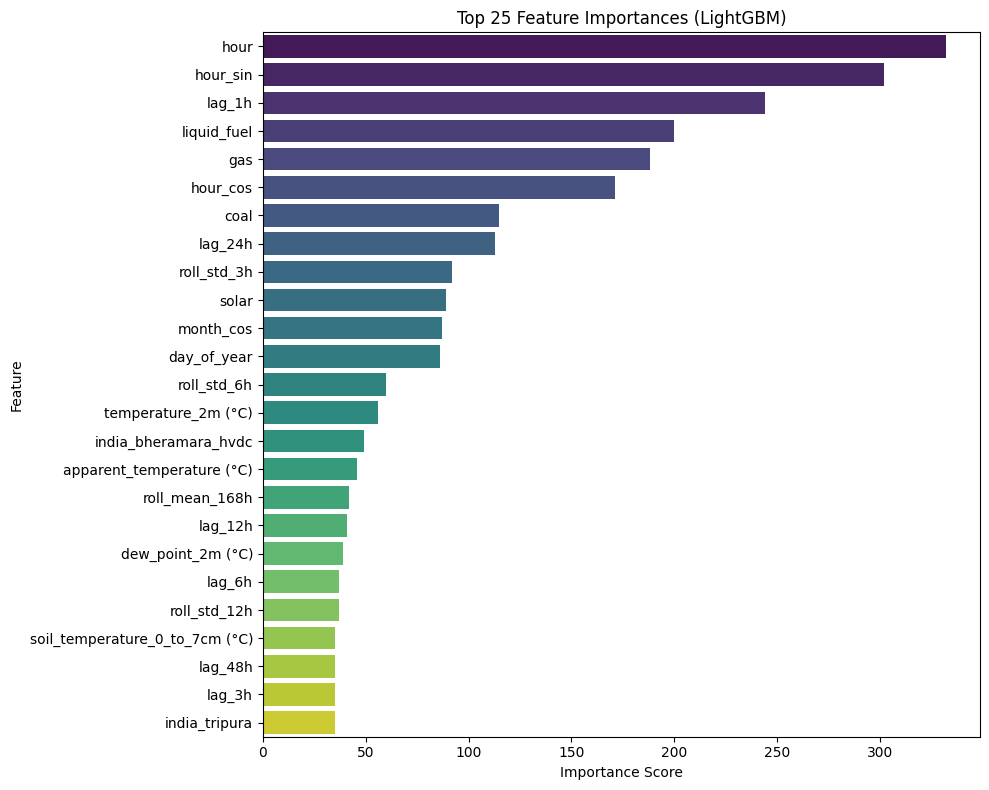

Top 10 most important features:
    feature  importance
       hour         332
   hour_sin         302
     lag_1h         244
liquid_fuel         200
        gas         188
   hour_cos         171
       coal         115
    lag_24h         113
roll_std_3h          92
      solar          89


In [39]:
# Feature importance shows which features the model relied on most
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 25 features
top_n = 25
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(
    data=importance_df.head(top_n),
    x='importance', y='feature',
    palette='viridis', ax=ax
)
ax.set_title(f'Top {top_n} Feature Importances (LightGBM)')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('graphs/feature_importance.png', dpi=150)
plt.show()

print('Top 10 most important features:')
print(importance_df.head(10).to_string(index=False))

---
## 8. Summary Report

### Missing Data & Outliers
- **Duplicates:** Removed duplicate timestamps, keeping the first occurrence.
- **Missing hours:** After reindexing to a perfect hourly grid, gaps were filled with linear interpolation (limited to 6 consecutive hours to avoid long extrapolation).
- **Outliers:** Used a rolling Z-score with a 168-hour (1-week) window and a threshold of 3.5 standard deviations. Detected anomalies were replaced with the local rolling mean, preserving trend while eliminating measurement errors.

### Temporal Features Engineered
| Feature | Why |
|---|---|
| `hour`, `hour_sin`, `hour_cos` | Captures intra-day patterns (peaks at morning/evening) |
| `day_of_week`, `is_weekend` | Weekdays have higher industrial demand |
| `month`, `month_sin`, `month_cos` | Seasonal temperature drives HVAC usage |
| `lag_1h` to `lag_12h` | Very short-term momentum |
| `lag_24h`, `lag_168h` | Same hour yesterday / last week (strongest signal) |
| `roll_mean_24h`, `roll_mean_168h` | Recent trend and weekly average level |
| `roll_std_24h` | Captures volatility periods |

### Key Insights from Feature Importance
*(Fill this in after running the notebook and seeing your feature importance plot)*
- Typically `lag_24h` and `lag_168h` are the top drivers — electricity demand follows strong daily and weekly cycles.
- `hour_sin/cos` are highly important — demand peaks during morning and evening hours.
- Weather (temperature) is important in regions with high HVAC usage.

### Final Model Performance
- **Model:** LightGBM Regressor
- **Test Period:** Full year 2023 (chronologically held out)
- **Test MAPE:** *(fill in after running)*